In [2]:
pip install psycopg2

     ---------------------------------------- 1.2/1.2 MB 4.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [16]:
import psycopg2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [6]:
host = 'localhost'
name_user = 'postgres'
password = '123'
database = 'SmartSocket'
connect = '5432'

In [109]:
try:
    connection = psycopg2.connect(host=host, user=name_user, password=password, database=database)
    connection.autocommit = True
    with connection.cursor() as cursor:
        cursor.execute('select * from data_voltage')
        data_voltage = cursor.fetchall()
except Exception as e:
    print(f'[info]: Ошибка {e}')
finally:
    if connection:
        connection.close()
        print('[info]: коннект закрыт')

[info]: коннект закрыт


In [110]:
col_voltage = ['num_measurements', 'uuid', 'time', 'flash_voltage', 'rms_voltage']

In [111]:
df_voltage = pd.DataFrame(data_voltage, columns=col)

In [112]:
df_voltage

,num_measurements,uuid,time,flash_voltage,rms_voltage
0,1,c8b6b828-7bef-4aa4-83a4-ed0fbc27e917,2026-02-07 12:30:38.349484,"[-287.7, -349.44, -349.44, -337.26, -307.86, -...",242.54
1,2,c8b6b828-7bef-4aa4-83a4-ed0fbc27e917,2026-02-07 12:30:43.422158,"[174.72, 267.54, 335.16, 349.86, 382.62, 326.7...",246.13
2,3,c8b6b828-7bef-4aa4-83a4-ed0fbc27e917,2026-02-07 12:30:48.553445,"[0.0, -78.12, -161.28, -222.18, -279.3, -311.6...",239.36
3,4,c8b6b828-7bef-4aa4-83a4-ed0fbc27e917,2026-02-07 12:30:53.718593,"[-235.2, -161.28, -79.8, 0.0, 105.0, 187.74, 2...",247.77
4,5,c8b6b828-7bef-4aa4-83a4-ed0fbc27e917,2026-02-07 12:30:58.995211,"[291.9, 159.18, 95.34, 0.0, -91.98, -181.44, -...",248.06
...,...,...,...,...,...
197,198,c8b6b828-7bef-4aa4-83a4-ed0fbc27e917,2026-02-07 13:38:37.821403,"[10.5, 109.62, 199.08, 295.68, 360.36, 373.8, ...",246.34
198,199,c8b6b828-7bef-4aa4-83a4-ed0fbc27e917,2026-02-07 13:39:06.199731,"[-17.22, -127.68, -217.56, -291.48, -334.74, -...",230.29
199,200,c8b6b828-7bef-4aa4-83a4-ed0fbc27e917,2026-02-07 13:39:11.120795,"[-9.66, -120.96, -209.16, -286.86, -313.32, -3...",246.97
200,201,c8b6b828-7bef-4aa4-83a4-ed0fbc27e917,2026-02-07 13:39:16.252967,"[-6.3, -120.12, -205.8, -278.04, -316.68, -312...",251.63


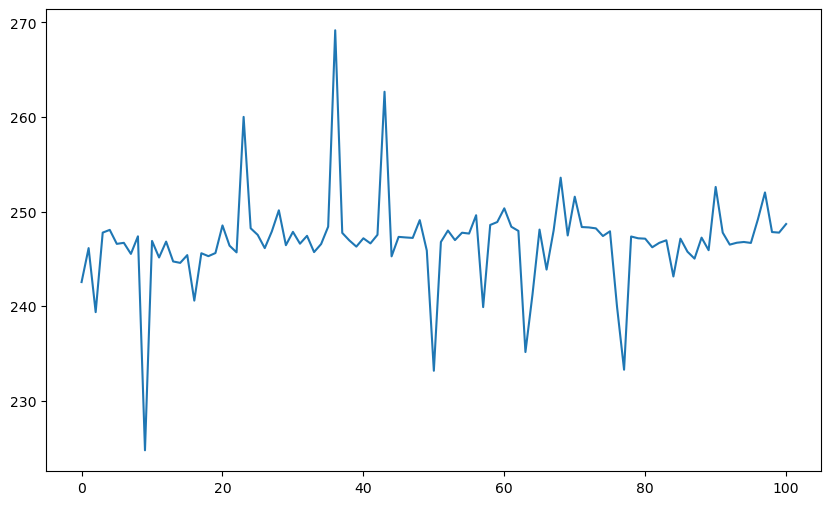

In [23]:
plt.figure(figsize=(10,6))
plt.plot(df_voltage['rms_voltage'])

In [48]:
one_test_data = df_voltage.iloc[0]['flash_voltage'][1:-1].split(', ')
one_test_data = np.array([float(i) for i in one_test_data])
one_test_data

array([-287.7 , -349.44, -349.44, -337.26, -307.86, -259.98, -181.86,
       -102.9 ,    0.  ,   80.22,  154.98,  236.46,  300.3 ,  315.42,
        334.74,  275.1 ,  215.04,  134.4 ,    0.  ,  -58.8 ])

In [49]:
two_test_data = df_voltage.iloc[1]['flash_voltage'][1:-1].split(', ')
two_test_data = np.array([float(i) for i in two_test_data])
two_test_data

array([ 174.72,  267.54,  335.16,  349.86,  382.62,  326.76,  275.94,
        190.26,   94.08,    0.  , -101.22, -174.72, -237.72, -289.38,
       -309.96, -309.54, -293.16, -267.54, -215.46, -140.28])

In [45]:
one_test_data.shape

(20,)

In [58]:
one_two_test_data = np.concatenate([one_test_data, two_test_data])

In [59]:
one_two_test_data

array([-287.7 , -349.44, -349.44, -337.26, -307.86, -259.98, -181.86,
       -102.9 ,    0.  ,   80.22,  154.98,  236.46,  300.3 ,  315.42,
        334.74,  275.1 ,  215.04,  134.4 ,    0.  ,  -58.8 ,  174.72,
        267.54,  335.16,  349.86,  382.62,  326.76,  275.94,  190.26,
         94.08,    0.  , -101.22, -174.72, -237.72, -289.38, -309.96,
       -309.54, -293.16, -267.54, -215.46, -140.28])

In [60]:
one_two_test_data.shape

(40,)

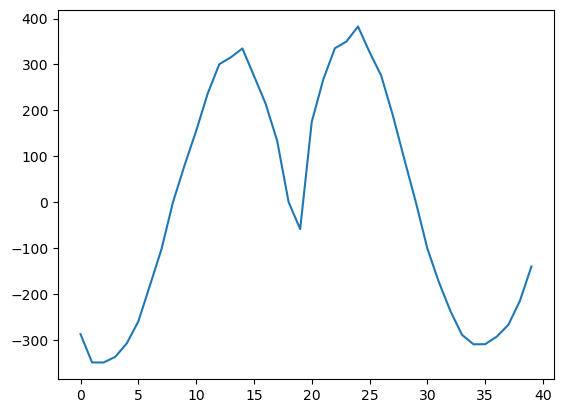

In [62]:
plt.plot(one_two_test_data)

In [63]:
try:
    connection = psycopg2.connect(host=host, user=name_user, password=password, database=database)
    connection.autocommit = True
    with connection.cursor() as cursor:
        cursor.execute('select * from data_current')
        data_current = cursor.fetchall()
except Exception as e:
    print(f'[info]: Ошибка {e}')
finally:
    if connection:
        connection.close()
        print('[info]: коннект закрыт')

[info]: коннект закрыт


In [64]:
col_current = ['num_measurements', 'uuid', 'time', 'flash_current', 'rms_current']

In [65]:
df_current = pd.DataFrame(data_current, columns=col_current)

In [66]:
df_current

,num_measurements,uuid,time,flash_current,rms_current
0,1,c8b6b828-7bef-4aa4-83a4-ed0fbc27e917,2026-02-07 12:30:38.346244,"[0.15, -0.05, -0.08, 0.26, 0.04, -0.06, -0.04,...",0.19
1,2,c8b6b828-7bef-4aa4-83a4-ed0fbc27e917,2026-02-07 12:30:43.417777,"[0.14, 0.1, 0.13, 0.08, 0.14, -0.09, 0.08, 0.0...",0.14
2,3,c8b6b828-7bef-4aa4-83a4-ed0fbc27e917,2026-02-07 12:30:48.545985,"[0.08, 0.11, 0.12, 0.12, 0.12, 0.13, 0.15, 0.5...",0.15
3,4,c8b6b828-7bef-4aa4-83a4-ed0fbc27e917,2026-02-07 12:30:53.711125,"[0.12, 0.12, 0.11, 0.1, 0.14, 0.13, 0.1, 0.12,...",0.14
4,5,c8b6b828-7bef-4aa4-83a4-ed0fbc27e917,2026-02-07 12:30:58.982849,"[0.0, -0.2, -0.08, -0.06, -0.1, -0.13, -0.08, ...",0.20
...,...,...,...,...,...
96,97,c8b6b828-7bef-4aa4-83a4-ed0fbc27e917,2026-02-07 12:38:52.671515,"[0.07, -0.23, -0.37, -0.16, -0.09, -0.05, -0.0...",0.18
97,98,c8b6b828-7bef-4aa4-83a4-ed0fbc27e917,2026-02-07 12:38:57.827179,"[0.13, 0.08, 0.13, 0.13, 0.33, 0.21, 0.13, 0.1...",0.12
98,99,c8b6b828-7bef-4aa4-83a4-ed0fbc27e917,2026-02-07 12:39:02.983259,"[0.1, 0.14, 0.14, 0.13, 0.11, 0.15, 0.15, -0.1...",0.12
99,100,c8b6b828-7bef-4aa4-83a4-ed0fbc27e917,2026-02-07 12:39:08.114373,"[0.08, 0.12, 0.11, 0.11, 0.13, 0.14, 0.14, 0.1...",0.12


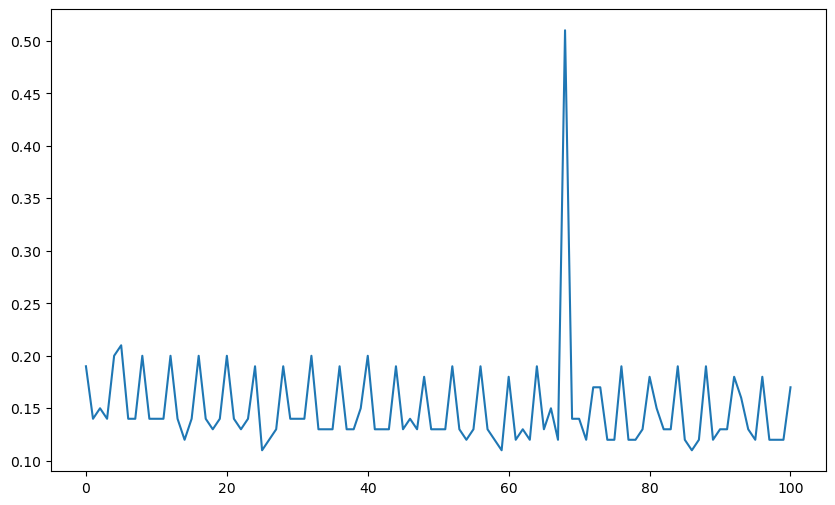

In [68]:
plt.figure(figsize=(10,6))
plt.plot(df_current['rms_current'])

In [79]:
one_test_data = df_current.iloc[0]['flash_current'][1:-1].split(', ')
one_test_data = np.array([float(i) for i in one_test_data])
one_test_data

array([ 0.15, -0.05, -0.08,  0.26,  0.04, -0.06, -0.04, -0.06, -0.05,
       -0.06, -0.06, -0.06, -0.06, -0.06, -0.51, -0.24, -0.07, -0.07,
       -0.08, -0.06])

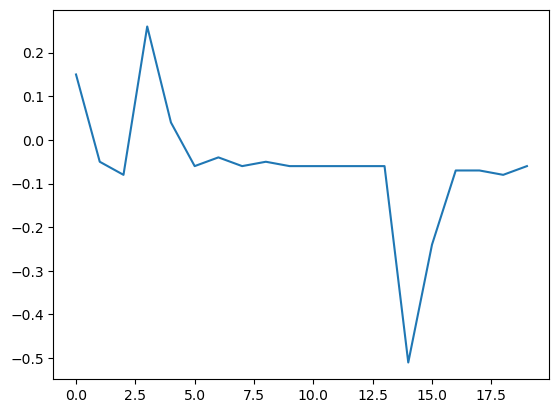

In [71]:
plt.plot(one_test_data)

In [80]:
one_test_data = pd.Series(one_test_data)

In [81]:
one_test_data

0     0.15
1    -0.05
2    -0.08
3     0.26
4     0.04
5    -0.06
6    -0.04
7    -0.06
8    -0.05
9    -0.06
10   -0.06
11   -0.06
12   -0.06
13   -0.06
14   -0.51
15   -0.24
16   -0.07
17   -0.07
18   -0.08
19   -0.06
dtype: float64

In [ ]:
one_test_data.

In [106]:
one_test_data = df_voltage.iloc[176]['flash_voltage'][1:-1].split(', ')
one_test_data = np.array([float(i) for i in one_test_data])
one_test_data

array([  -6.72, -107.52, -188.16, -257.46, -307.02, -322.14, -311.64,
       -274.26, -222.6 , -134.82,  -32.76,   67.2 ,  156.24,  255.36,
        328.86,  362.04,  370.44,  309.54,  248.64,  147.84])

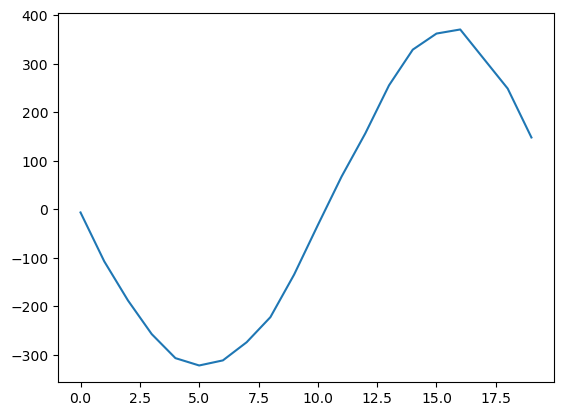

In [107]:
plt.plot(one_test_data)

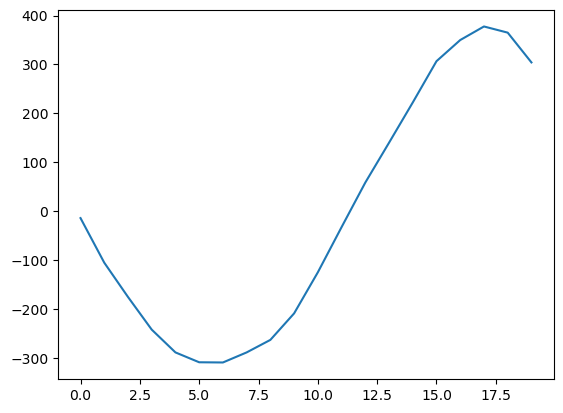

In [108]:
one_test_data = df_voltage.iloc[126]['flash_voltage'][1:-1].split(', ')
one_test_data = np.array([float(i) for i in one_test_data])
plt.plot(one_test_data)

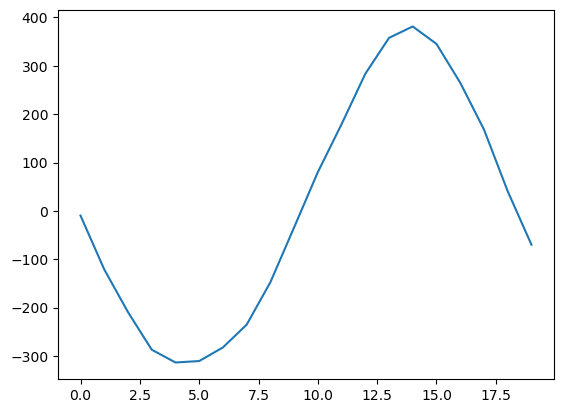

In [115]:
one_test_data = df_voltage.iloc[199]['flash_voltage'][1:-1].split(', ')
one_test_data = np.array([float(i) for i in one_test_data])
plt.plot(one_test_data)